# Telco Churn Prediction & Retention Analysis

## 1. Project Introduction

Customer churn occurs when customers stop using a company's services. For telecommunications companies, understanding churn is important because losing existing customers can affect recurring revenue and increase the need for customer acquisition.

The purpose of this project is to analyze customer behavior and service-related factors associated with churn and to develop a machine learning approach for identifying customers who may be at higher risk of leaving.

Beyond prediction, the project aims to translate model results into meaningful insights that could support customer-retention strategies.

## 2. Dataset Description

The dataset contains information about **7,043 telecommunications customers** and **21 variables**.

The features describe several aspects of each customer, including:

- **Customer demographics:** gender, senior-citizen status, partner, and dependents
- **Account information:** tenure, contract type, payment method, paperless billing
- **Services:** phone service, internet service, online security, online backup, device protection, tech support, streaming TV, and streaming movies
- **Billing information:** monthly charges and total charges
- **Target variable:** `Churn`, indicating whether a customer left the company

Each observation represents an individual customer, while `customerID` serves as the customer identifier.

## 3. Problem Statement

The main analytical question of this project is:

**Can customer information and service-usage patterns be used to identify customers at risk of churn, and what factors are most strongly associated with their decision to leave?**

This is treated as a **binary classification problem**, where:

- `No` = Customer did not churn
- `Yes` = Customer churned

## 4. Project Objectives

The project aims to:

1. Assess and improve the quality of the dataset.
2. Explore patterns and relationships associated with customer churn.
3. Identify important customer and service characteristics linked to churn.
4. Engineer useful features for predictive modeling.
5. Develop and compare multiple machine learning models.
6. Evaluate model performance using appropriate classification metrics.
7. Interpret model predictions to identify important churn drivers.
8. Convert analytical findings into practical customer-retention recommendations.

## 5. Project Workflow

The analysis follows the following workflow:

**Data Understanding → Data Quality Assessment → Data Cleaning → Exploratory Data Analysis → Feature Engineering → Data Preparation → Predictive Modeling → Model Evaluation → Model Explainability → Business Insights & Retention Recommendations**

## 6. Data Loading & Initial Inspection

In this section, the dataset is loaded and inspected to understand its dimensions, structure, feature types, and initial observations before performing any preprocessing or analysis.

In [1]:
# Load the dataset

import pandas as pd
import numpy as np

file_path = "/kaggle/input/datasets/maham1199/telco-customer-churn-dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

display(df.head())

Dataset loaded successfully.
Dataset contains 7043 rows and 21 columns.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Dataset dimensions

print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])

Number of observations: 7043
Number of variables: 21


In [3]:
# Display all column names

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

1. customerID
2. gender
3. SeniorCitizen
4. Partner
5. Dependents
6. tenure
7. PhoneService
8. MultipleLines
9. InternetService
10. OnlineSecurity
11. OnlineBackup
12. DeviceProtection
13. TechSupport
14. StreamingTV
15. StreamingMovies
16. Contract
17. PaperlessBilling
18. PaymentMethod
19. MonthlyCharges
20. TotalCharges
21. Churn


In [4]:
# Check data types

df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [5]:
# General dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 6.1 Initial Observations

The initial inspection of the dataset shows:

- The dataset contains **7,043 customer records and 21 variables**.
- The variables consist of **18 object-type, 2 integer-type, and 1 float-type columns**.
- Most service, demographic, contract, and billing-related attributes are stored as categorical variables.
- `tenure` and `SeniorCitizen` are stored as integers, while `MonthlyCharges` is stored as a floating-point numerical variable.
- `customerID` is a unique customer identifier and is not expected to provide meaningful predictive information for churn modeling.
- `Churn` is the target variable and is currently stored as a categorical (`object`) variable.
- `TotalCharges` represents a monetary amount but is stored as an `object` rather than a numerical data type. This suggests that the column may contain blank or non-numeric values and requires further investigation.
- Based on the standard non-null counts, all 21 columns contain 7,043 non-null observations. However, additional checks are required because blank strings or other hidden values may not be detected as standard missing values.

## 7. Data Quality Assessment

Before performing exploratory data analysis or predictive modeling, the dataset is systematically assessed for potential quality issues.

The assessment focuses on:

- Missing and blank values
- Incorrect data types
- Duplicate records
- Customer identifier uniqueness
- Categorical value consistency
- Numerical value ranges
- Target-class distribution

Identifying these issues before preprocessing helps prevent unreliable analysis and potential modeling errors.

In [6]:
# Check standard missing values

missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary

,Missing_Count,Missing_Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


### 7.1 Blank-Value Investigation

Standard missing-value detection does not always identify empty strings or values containing only whitespace. Therefore, object-type columns are additionally checked for blank values.

In [7]:
# Check blank or whitespace-only values in object columns

object_columns = df.select_dtypes(include="object").columns

blank_counts = {}

for col in object_columns:
    blank_counts[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

blank_summary = pd.DataFrame(
    list(blank_counts.items()),
    columns=["Column", "Blank_Count"]
)

blank_summary = blank_summary[
    blank_summary["Blank_Count"] > 0
].reset_index(drop=True)

blank_summary

,Column,Blank_Count
0,TotalCharges,11


In [8]:
# Examine records with blank TotalCharges

blank_total_charges = df[
    df["TotalCharges"].astype(str).str.strip().eq("")
]

blank_total_charges

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [9]:
# Examine tenure and charges for customers with blank TotalCharges

blank_total_charges[
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [10]:
df.dropna()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


### Finding: Blank Values in `TotalCharges`

The standard missing-value check did not identify any null values. However,
a whitespace-based inspection revealed **11 blank values** in `TotalCharges`.

Further examination showed that all 11 affected customers have a `tenure`
of **0 months**. This indicates that the blank values are associated with
new customers who have not yet accumulated historical total charges.

Therefore, these records are not treated as arbitrary missing observations.
An appropriate treatment will be selected during the data-cleaning stage
while preserving the customer records.

### 7.2 Duplicate and Customer Identifier Assessment

Duplicate records can bias descriptive statistics and predictive models.
The dataset is therefore examined for exact duplicate rows, duplicate
customer identifiers, and repeated customer profiles.

In [11]:
# Check exact duplicates and customer ID uniqueness

print("Total observations:", len(df))
print("Unique customer IDs:", df["customerID"].nunique())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())
print("Exact duplicate rows:", df.duplicated().sum())

Total observations: 7043
Unique customer IDs: 7043
Duplicate customer IDs: 0
Exact duplicate rows: 0


In [12]:
# Check repeated records after excluding the unique customer identifier

features_without_id = df.drop(columns=["customerID"])

duplicate_profiles = features_without_id.duplicated(keep=False)

print("Rows belonging to repeated profiles:", duplicate_profiles.sum())
print(
    "Number of exact duplicate rows excluding customerID:",
    features_without_id.duplicated().sum()
)

Rows belonging to repeated profiles: 42
Number of exact duplicate rows excluding customerID: 22


In [13]:
# Inspect unique values in categorical variables

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}")
    print("-" * 50)
    print(df[col].value_counts(dropna=False))


customerID
--------------------------------------------------
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

gender
--------------------------------------------------
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
--------------------------------------------------
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
--------------------------------------------------
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
--------------------------------------------------
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
--------------------------------------------------
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
--------------------

#### Findings: Duplicate Assessment

- All **7,043 customer IDs are unique**, indicating that each row represents a separately identified customer.
- No completely duplicated rows were found when `customerID` was included.
- After excluding `customerID`, **42 rows belonged to repeated customer profiles**, corresponding to **22 duplicated rows** under the standard duplicate-counting method.
- These repeated profiles are not automatically considered data errors. Different customers may legitimately share identical demographic, service, billing, and churn characteristics.
- Therefore, these observations are retained at this stage rather than being removed solely on the basis of matching feature values.

#### Findings: Categorical Value Assessment

Inspection of the categorical variables showed consistent and interpretable
category labels, with no obvious spelling inconsistencies or unexpected
categories.

Several service-related variables contain categories such as
`No internet service` or `No phone service`. These values are retained as
meaningful categories because they distinguish customers who do not have
access to the underlying service from customers who have the service but
do not subscribe to a particular feature.

The target variable `Churn` contains two classes:

- `No`: 5,174 customers
- `Yes`: 1,869 customers

The difference between the two classes indicates class imbalance, which
will be considered during model evaluation and, if necessary, during
model development.

### 7.3 Numerical Data Validation

Numerical variables are examined for their distributions, ranges, and
potentially invalid values. Since `TotalCharges` is currently stored as an
object due to blank entries, a temporary numeric representation is created
for assessment without modifying the original dataset.

In [14]:
# Create temporary numeric version of TotalCharges

total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Original TotalCharges dtype:", df["TotalCharges"].dtype)
print("Temporary numeric dtype:", total_charges_numeric.dtype)
print("Values converted to NaN:", total_charges_numeric.isna().sum())

Original TotalCharges dtype: object
Temporary numeric dtype: float64
Values converted to NaN: 11


In [15]:
# Descriptive statistics for numerical variables

numeric_summary = pd.DataFrame({
    "tenure": df["tenure"],
    "MonthlyCharges": df["MonthlyCharges"],
    "TotalCharges": total_charges_numeric
}).describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


In [16]:
# Check numerical ranges and potentially invalid values

print("Tenure range:")
print("Minimum:", df["tenure"].min())
print("Maximum:", df["tenure"].max())

print("\nMonthlyCharges range:")
print("Minimum:", df["MonthlyCharges"].min())
print("Maximum:", df["MonthlyCharges"].max())

print("\nTotalCharges range (excluding blanks):")
print("Minimum:", total_charges_numeric.min())
print("Maximum:", total_charges_numeric.max())

print("\nPotential invalid values:")
print("Negative tenure:", (df["tenure"] < 0).sum())
print("Negative MonthlyCharges:", (df["MonthlyCharges"] < 0).sum())
print("Negative TotalCharges:", (total_charges_numeric < 0).sum())

Tenure range:
Minimum: 0
Maximum: 72

MonthlyCharges range:
Minimum: 18.25
Maximum: 118.75

TotalCharges range (excluding blanks):
Minimum: 18.8
Maximum: 8684.8

Potential invalid values:
Negative tenure: 0
Negative MonthlyCharges: 0
Negative TotalCharges: 0


In [17]:
# Validate relationship between zero tenure and blank TotalCharges

zero_tenure = df["tenure"].eq(0)
blank_charges = df["TotalCharges"].astype(str).str.strip().eq("")

print("Customers with tenure = 0:", zero_tenure.sum())
print("Customers with blank TotalCharges:", blank_charges.sum())
print(
    "Tenure = 0 AND blank TotalCharges:",
    (zero_tenure & blank_charges).sum()
)

Customers with tenure = 0: 11
Customers with blank TotalCharges: 11
Tenure = 0 AND blank TotalCharges: 11


#### Findings: Numerical Data Validation

The numerical variables were examined for data types, ranges, and potentially
invalid values.

- `tenure` ranges from **0 to 72 months**, with a mean of approximately
  **32.37 months**.
- `MonthlyCharges` ranges from **18.25 to 118.75**, with an average of
  approximately **64.76**.
- After temporary numeric conversion, `TotalCharges` ranges from **18.80
  to 8,684.80**, with an average of approximately **2,283.30**.
- No negative values were identified in `tenure`, `MonthlyCharges`, or
  `TotalCharges`.
- Converting `TotalCharges` to a numeric format produced **11 missing
  values**, corresponding exactly to the previously identified blank entries.
- All **11 customers with blank `TotalCharges` also have a tenure of
  0 months**, and all customers with zero tenure belong to this group.

This relationship suggests that the missing `TotalCharges` values are
systematically associated with newly enrolled customers rather than random
missing data.

## 8. Data Cleaning

Based on the data quality assessment, the following cleaning steps are
performed before exploratory analysis and modeling:

1. Convert `TotalCharges` from an object to a numerical variable.
2. Replace the 11 blank `TotalCharges` values associated with zero-tenure
   customers with 0.
3. Preserve repeated customer profiles because each record has a unique
   customer identifier and matching profiles do not necessarily represent
   duplicate customers.
4. Retain meaningful service-status categories such as
   `No internet service` and `No phone service`.
5. Preserve the original customer records without removing observations
   unnecessarily.

In [18]:
# Create a copy for cleaning

df_clean = df.copy()

print("Original dataset shape:", df.shape)
print("Cleaning dataset shape:", df_clean.shape)

Original dataset shape: (7043, 21)
Cleaning dataset shape: (7043, 21)


In [19]:
# Convert TotalCharges to numeric

df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

print("TotalCharges dtype:", df_clean["TotalCharges"].dtype)
print("Missing TotalCharges:", df_clean["TotalCharges"].isna().sum())

TotalCharges dtype: float64
Missing TotalCharges: 11


In [20]:
# Set TotalCharges to 0 for new customers with zero tenure

mask = (
    df_clean["TotalCharges"].isna()
    & df_clean["tenure"].eq(0)
)

print("Records meeting condition:", mask.sum())

df_clean.loc[mask, "TotalCharges"] = 0

print("Remaining missing TotalCharges:",
      df_clean["TotalCharges"].isna().sum())

Records meeting condition: 11
Remaining missing TotalCharges: 0


In [21]:
# Verify data cleaning

print("=" * 50)
print("CLEANING VERIFICATION")
print("=" * 50)

print("\nDataset shape:", df_clean.shape)
print("Total missing values:", df_clean.isnull().sum().sum())
print("Exact duplicate rows:", df_clean.duplicated().sum())
print("Unique customer IDs:", df_clean["customerID"].nunique())
print("TotalCharges dtype:", df_clean["TotalCharges"].dtype)

print("\nNumerical ranges:")
print("Tenure:", df_clean["tenure"].min(), "to",
      df_clean["tenure"].max())
print("MonthlyCharges:", df_clean["MonthlyCharges"].min(), "to",
      df_clean["MonthlyCharges"].max())
print("TotalCharges:", df_clean["TotalCharges"].min(), "to",
      df_clean["TotalCharges"].max())

CLEANING VERIFICATION

Dataset shape: (7043, 21)
Total missing values: 0
Exact duplicate rows: 0
Unique customer IDs: 7043
TotalCharges dtype: float64

Numerical ranges:
Tenure: 0 to 72
MonthlyCharges: 18.25 to 118.75
TotalCharges: 0.0 to 8684.8


### 8.1 Cleaning Summary

After the data quality assessment and cleaning process:

- All **7,043 customer records** were retained.
- `TotalCharges` was successfully converted from an object to a numerical variable.
- The **11 blank `TotalCharges` values** associated exclusively with zero-tenure customers were assigned a value of 0.
- No standard missing values remain in the cleaned dataset.
- No exact duplicate records were identified.
- All **7,043 customer identifiers remain unique**.
- Meaningful categorical service-status values were preserved.

The cleaned dataset is therefore ready for exploratory data analysis.

## 9. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand customer
characteristics, identify patterns associated with churn, and generate
hypotheses for subsequent predictive modeling.

The analysis begins with the target variable and progressively examines
demographic, account, service, and financial characteristics.

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [23]:
# Churn distribution

churn_summary = pd.DataFrame({
    "Count": df_clean["Churn"].value_counts(),
    "Percentage (%)":
        df_clean["Churn"].value_counts(normalize=True).mul(100).round(2)
})

churn_summary

,Count,Percentage (%)
Churn,,
No,5174,73.46
Yes,1869,26.54


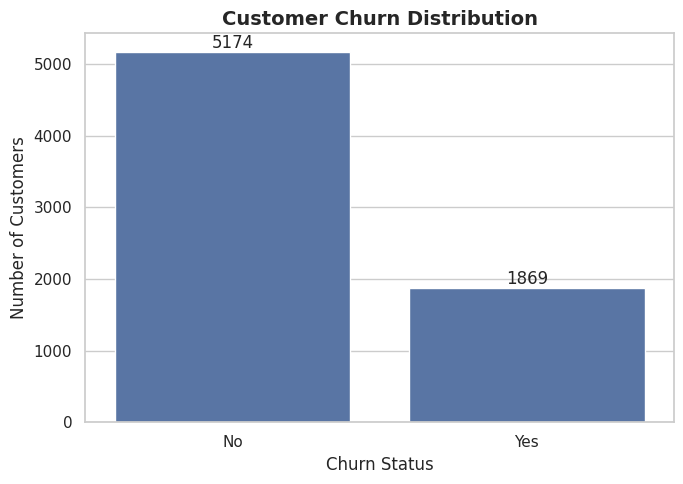

In [24]:
# Visualize customer churn distribution

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df_clean,
    x="Churn"
)

plt.title("Customer Churn Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

# Add counts above bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

#### Observation

Approximately **26.5% of customers churned**, while **73.5% remained**.
This indicates a noticeable class imbalance, with non-churn customers
representing roughly three-quarters of the dataset.

Because accuracy alone could therefore provide a misleading assessment
of predictive performance, additional metrics such as precision, recall,
F1-score, ROC-AUC, and PR-AUC will be considered during model evaluation.

In [25]:
# Churn rate by gender

gender_churn = pd.crosstab(
    df_clean["gender"],
    df_clean["Churn"],
    normalize="index"
).mul(100).round(2)

gender_churn

Churn,No,Yes
gender,,
Female,73.08,26.92
Male,73.84,26.16


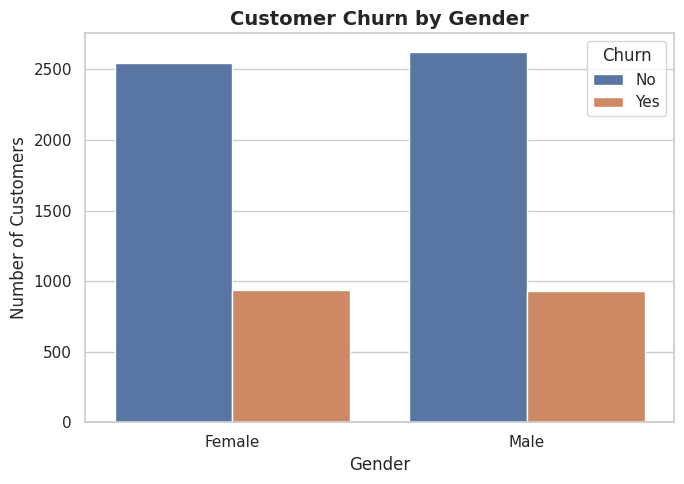

In [26]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="gender",
    hue="Churn"
)

plt.title("Customer Churn by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

In [27]:
# Create readable senior-citizen labels for visualization

df_clean["SeniorCitizenLabel"] = df_clean["SeniorCitizen"].map({
    0: "No",
    1: "Yes"
})

In [28]:
senior_churn = pd.crosstab(
    df_clean["SeniorCitizenLabel"],
    df_clean["Churn"],
    normalize="index"
).mul(100).round(2)

senior_churn

Churn,No,Yes
SeniorCitizenLabel,,
No,76.39,23.61
Yes,58.32,41.68


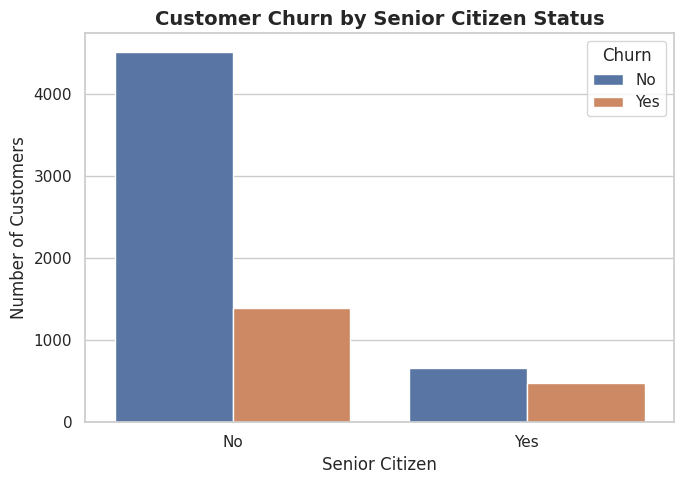

In [29]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="SeniorCitizenLabel",
    hue="Churn"
)

plt.title("Customer Churn by Senior Citizen Status",
          fontsize=14, fontweight="bold")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

### 9.1 Gender and Churn — Observation

The churn rate is very similar across gender groups:

- **Female customers:** 26.92% churn
- **Male customers:** 26.16% churn

The difference is less than one percentage point, suggesting that gender
alone is unlikely to be a strong discriminator of customer churn in this
dataset.

### 9.2 Senior Citizen Status and Churn — Observation

A noticeable difference is observed between senior and non-senior customers:

- **Non-senior customers:** 23.61% churn
- **Senior customers:** 41.68% churn

Senior customers therefore exhibit a substantially higher churn rate in
this dataset. This suggests that senior-citizen status may be associated
with churn risk and warrants further investigation alongside other
customer characteristics.

This relationship is descriptive and should not be interpreted as causal,
as other factors such as contract type, service selection, tenure, or
billing characteristics may also contribute to the observed difference.

### 9.3 Partner and Dependents

The relationship between customers' household characteristics and churn
is examined to determine whether customers with partners or dependents
show different churn patterns.

In [30]:
# Churn rate by partner status

partner_churn = pd.crosstab(
    df_clean["Partner"],
    df_clean["Churn"],
    normalize="index"
).mul(100).round(2)

partner_churn

Churn,No,Yes
Partner,,
No,67.04,32.96
Yes,80.34,19.66


In [31]:
# Churn rate by dependent status

dependents_churn = pd.crosstab(
    df_clean["Dependents"],
    df_clean["Churn"],
    normalize="index"
).mul(100).round(2)

dependents_churn

Churn,No,Yes
Dependents,,
No,68.72,31.28
Yes,84.55,15.45


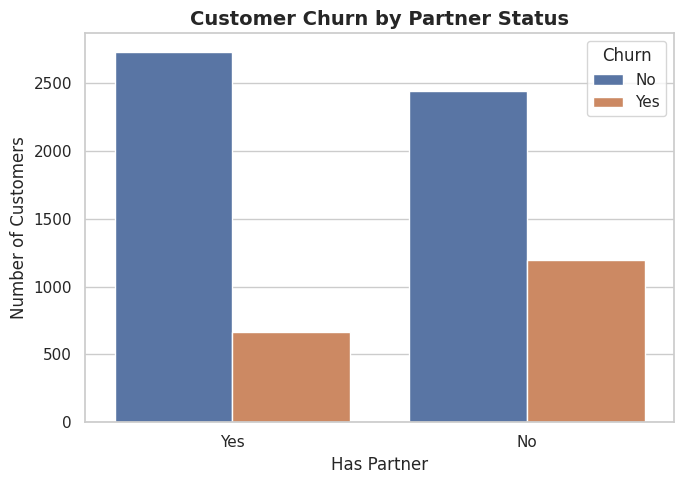

In [32]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="Partner",
    hue="Churn"
)

plt.title("Customer Churn by Partner Status",
          fontsize=14, fontweight="bold")
plt.xlabel("Has Partner")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

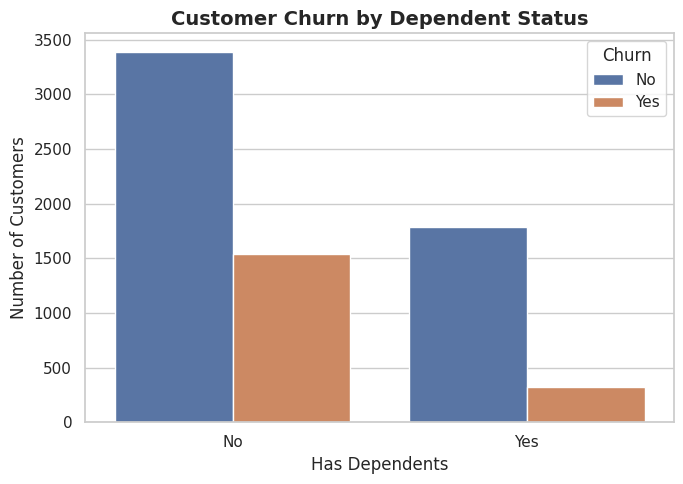

In [33]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="Dependents",
    hue="Churn"
)

plt.title("Customer Churn by Dependent Status",
          fontsize=14, fontweight="bold")
plt.xlabel("Has Dependents")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

### 9.4 Customer Tenure and Churn

Customer tenure represents the number of months a customer has remained
with the company. The distribution of tenure is examined across churn
groups to determine whether customer longevity is associated with churn.

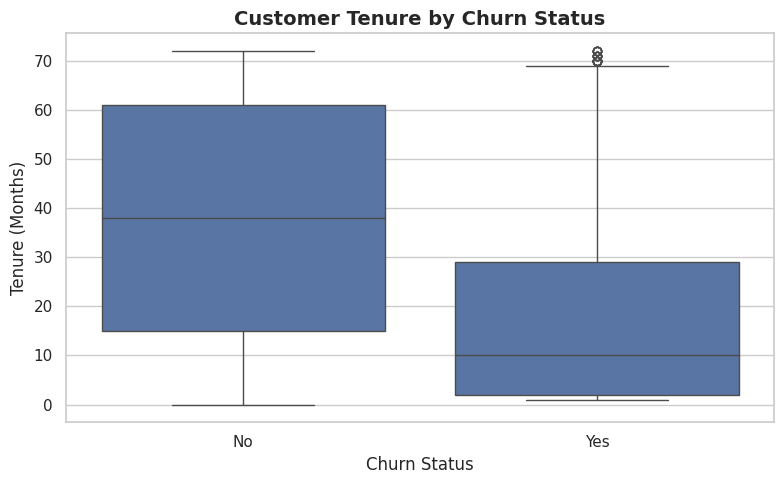

In [34]:
# Compare tenure between churn groups

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status",
          fontsize=14, fontweight="bold")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

In [35]:
# Tenure statistics by churn status

tenure_summary = df_clean.groupby("Churn")["tenure"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

tenure_summary

,count,mean,median,std,min,max
Churn,,,,,,
No,5174,37.57,38.0,24.11,0,72
Yes,1869,17.98,10.0,19.53,1,72


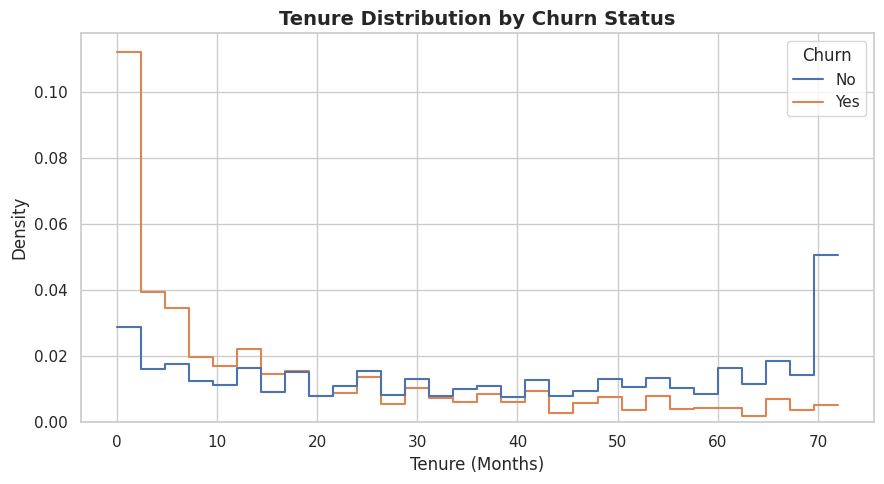

In [36]:
# Tenure distribution by churn status

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_clean,
    x="tenure",
    hue="Churn",
    bins=30,
    stat="density",
    common_norm=False,
    multiple="layer",
    element="step",
    fill=False
)

plt.title(
    "Tenure Distribution by Churn Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Tenure (Months)")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

### 9.5 Contract Type and Churn

Contract duration may influence customer retention because customers with
different contractual commitments may exhibit different churn behavior.
Churn rates are therefore compared across month-to-month, one-year, and
two-year contracts.

In [37]:
# Churn rate by contract type

contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
).mul(100).round(2)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [38]:
# Calculate churn rate for each contract type

contract_rate = (
    df_clean.assign(ChurnFlag=df_clean["Churn"].map({"No": 0, "Yes": 1}))
    .groupby("Contract")["ChurnFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

contract_rate.columns = ["Contract", "ChurnRate"]

contract_rate

,Contract,ChurnRate
0,Month-to-month,42.709677
1,One year,11.269518
2,Two year,2.831858


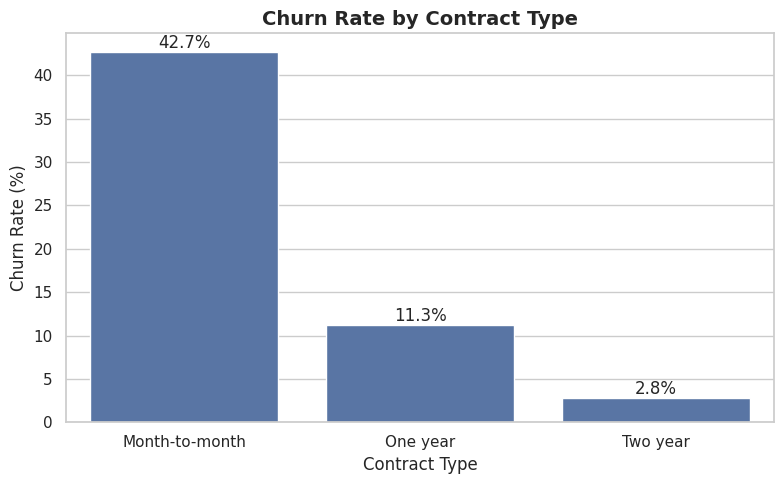

In [39]:
# Visualize churn rate by contract type

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=contract_rate,
    x="Contract",
    y="ChurnRate"
)

plt.title("Churn Rate by Contract Type",
          fontsize=14, fontweight="bold")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

#### Key Observations: Tenure and Contract Type

**Customer Tenure**

A substantial difference in tenure is observed between customers who
churned and those who remained with the company.

- Customers who did not churn had an average tenure of **37.57 months**
  and a median tenure of **38 months**.
- Customers who churned had a considerably lower average tenure of
  **17.98 months** and a median tenure of only **10 months**.
- The tenure distribution further shows that churn is concentrated among
  relatively newer customers, whereas long-tenure customers are more
  strongly represented among those who remain.

These results suggest a strong association between shorter customer
relationships and churn.

**Contract Type**

Contract duration shows an especially pronounced relationship with churn:

- **Month-to-month:** 42.71% churn
- **One-year:** 11.27% churn
- **Two-year:** 2.83% churn

Customers on month-to-month contracts therefore exhibit a substantially
higher churn rate than customers with longer-term contracts. The pattern
suggests that contractual commitment is strongly associated with customer
retention.

These findings represent associations within the dataset and should not
be interpreted as evidence that tenure or contract type directly causes
customer churn.

### 9.6 Internet Service and Churn

Churn rates are compared across internet-service categories to examine
whether customers using different types of internet services exhibit
different retention patterns.

In [40]:
# Churn rate by internet service

internet_churn = pd.crosstab(
    df_clean["InternetService"],
    df_clean["Churn"],
    normalize="index"
).mul(100).round(2)

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


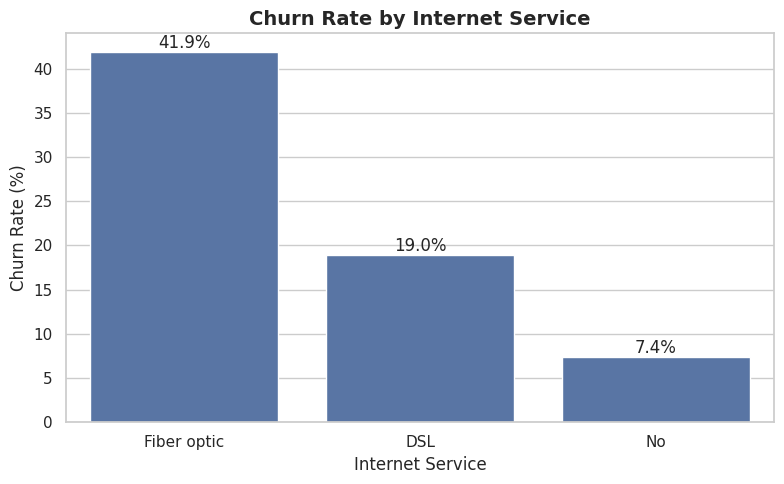

In [41]:
# Calculate churn rate by internet service

internet_rate = (
    df_clean
    .assign(ChurnFlag=df_clean["Churn"].map({"No": 0, "Yes": 1}))
    .groupby("InternetService")["ChurnFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

internet_rate.columns = ["InternetService", "ChurnRate"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=internet_rate,
    x="InternetService",
    y="ChurnRate"
)

plt.title(
    "Churn Rate by Internet Service",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

In [42]:
# Churn rate by online security status

security_churn = pd.crosstab(
    df_clean["OnlineSecurity"],
    df_clean["Churn"],
    normalize="index"
).mul(100).round(2)

security_churn

Churn,No,Yes
OnlineSecurity,,
No,58.23,41.77
No internet service,92.60,7.40
Yes,85.39,14.61


In [43]:
# Churn rate by tech support status

support_churn = pd.crosstab(
    df_clean["TechSupport"],
    df_clean["Churn"],
    normalize="index"
).mul(100).round(2)

support_churn

Churn,No,Yes
TechSupport,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17


#### Key Observations: Online Security and Tech Support

**Online Security**

- Customers without Online Security have a churn rate of **41.77%**.
- Customers with Online Security have a substantially lower churn rate of
  **14.61%**.
- Customers without internet service show a churn rate of **7.40%**.

**Tech Support**

- Customers without Tech Support have a churn rate of **41.64%**.
- Customers with Tech Support have a considerably lower churn rate of
  **15.17%**.
- Customers without internet service again show a churn rate of **7.40%**.

The results indicate that, among customers using internet-related services,
Online Security and Tech Support availability are associated with lower
churn rates. However, these relationships are descriptive and may also
reflect differences in tenure, contract type, charges, or other customer
characteristics.

### 9.7 Monthly Charges and Churn

Monthly charges are examined across churn groups to determine whether
customers who leave the company tend to have different recurring charges
from customers who remain.

In [44]:
# Monthly charge statistics by churn status

monthly_summary = (
    df_clean
    .groupby("Churn")["MonthlyCharges"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

monthly_summary

,count,mean,median,std,min,max
Churn,,,,,,
No,5174,61.27,64.43,31.09,18.25,118.75
Yes,1869,74.44,79.65,24.67,18.85,118.35


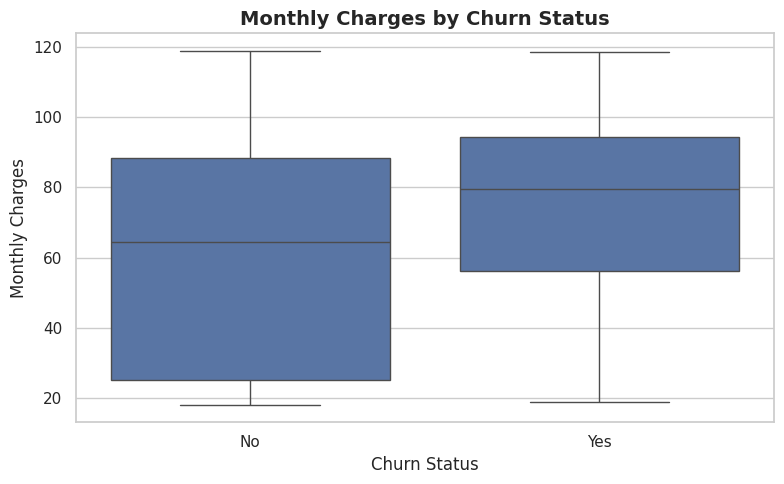

In [45]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges"
)

plt.title(
    "Monthly Charges by Churn Status",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

### 9.8 Total Charges and Churn

Total accumulated charges are compared between churn groups to examine
whether overall customer spending differs between customers who remain
and those who leave.

In [46]:
# Total charge statistics by churn status

total_summary = (
    df_clean
    .groupby("Churn")["TotalCharges"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

total_summary

,count,mean,median,std,min,max
Churn,,,,,,
No,5174,2549.91,1679.52,2329.95,0.00,8672.45
Yes,1869,1531.80,703.55,1890.82,18.85,8684.80


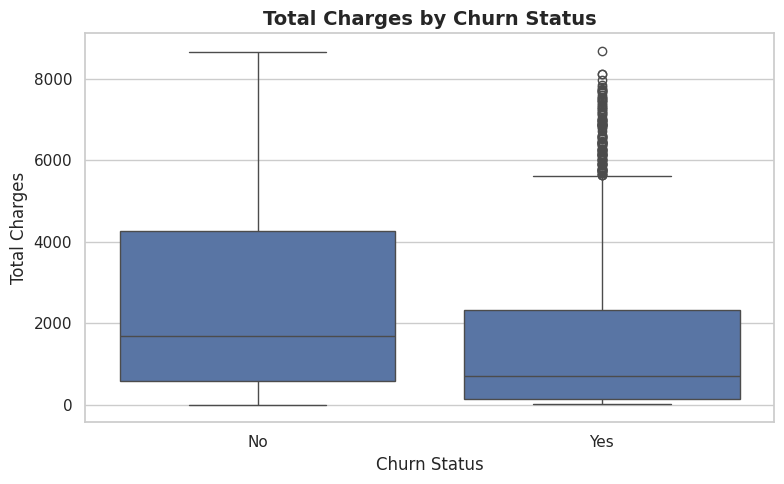

In [47]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="TotalCharges"
)

plt.title(
    "Total Charges by Churn Status",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Churn Status")
plt.ylabel("Total Charges")

plt.tight_layout()
plt.show()

#### Key Observations: Monthly and Total Charges

**Monthly Charges**

Customers who churned generally had higher recurring monthly charges:

- Non-churn customers: mean = **61.27**, median = **64.43**
- Churn customers: mean = **74.44**, median = **79.65**

This indicates that customers who churn tend to have higher monthly
charges than customers who remain.

**Total Charges**

The opposite pattern is observed for accumulated total charges:

- Non-churn customers: mean = **2,549.91**, median = **1,679.52**
- Churn customers: mean = **1,531.80**, median = **703.55**

Although churned customers have higher monthly charges, their accumulated
total charges are considerably lower. This pattern is consistent with the
earlier tenure analysis, where churned customers were found to have much
shorter customer relationships.

Therefore, `TotalCharges` should be interpreted together with `tenure`
rather than as an independent indicator of customer spending behavior.

These relationships are descriptive and do not establish that higher
monthly charges directly cause customer churn.

### 9.9 Payment Method and Churn

Churn rates are compared across payment methods to determine whether
customers using different billing mechanisms exhibit different retention
patterns.

In [48]:
# Churn rate by payment method

payment_churn = pd.crosstab(
    df_clean["PaymentMethod"],
    df_clean["Churn"],
    normalize="index"
).mul(100).round(2)

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


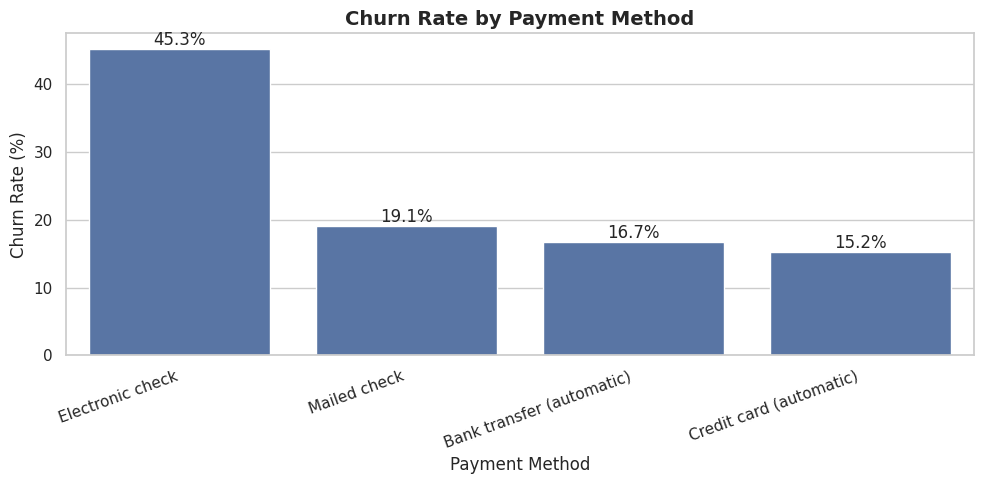

In [49]:
# Calculate churn rate by payment method

payment_rate = (
    df_clean
    .assign(ChurnFlag=df_clean["Churn"].map({"No": 0, "Yes": 1}))
    .groupby("PaymentMethod")["ChurnFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

payment_rate.columns = ["PaymentMethod", "ChurnRate"]

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=payment_rate,
    x="PaymentMethod",
    y="ChurnRate"
)

plt.title(
    "Churn Rate by Payment Method",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

### 9.10 Paperless Billing and Churn

The relationship between paperless billing and customer churn is examined
to determine whether billing preference is associated with retention.

In [50]:
# Churn rate by paperless billing status

paperless_churn = pd.crosstab(
    df_clean["PaperlessBilling"],
    df_clean["Churn"],
    normalize="index"
).mul(100).round(2)

paperless_churn

Churn,No,Yes
PaperlessBilling,,
No,83.67,16.33
Yes,66.43,33.57


#### Key Observations: Payment Method and Paperless Billing

**Payment Method**

A substantial difference in churn rate is observed across payment methods:

- Electronic check: **45.29%**
- Mailed check: **19.11%**
- Bank transfer (automatic): **16.71%**
- Credit card (automatic): **15.24%**

Customers using electronic checks exhibit the highest churn rate by a
considerable margin. In contrast, customers using automatic payment
methods show substantially lower churn rates.

**Paperless Billing**

Customers using paperless billing have a churn rate of **33.57%**, compared
with **16.33%** among customers who do not use paperless billing.

These findings indicate associations between billing characteristics and
churn. However, payment method and paperless billing may also be related
to other characteristics such as contract type, tenure, service selection,
and monthly charges. Therefore, these relationships should not be
interpreted as causal effects.

### 9.11 Contract Type, Monthly Charges, and Churn

Because both contract type and monthly charges showed notable relationships
with churn individually, their combined relationship is examined to
determine whether monthly-charge patterns differ across contract groups.

In [51]:
# Monthly charges by contract type and churn status

contract_charge_summary = (
    df_clean
    .groupby(["Contract", "Churn"])["MonthlyCharges"]
    .agg(["count", "mean", "median"])
    .round(2)
)

contract_charge_summary

count   mean  median
Contract       Churn                      
Month-to-month No      2220  61.46   64.95
               Yes     1655  73.02   79.05
One year       No      1307  62.51   64.85
               Yes      166  85.05   95.05
Two year       No      1647  60.01   63.30
               Yes       48  86.78   97.28

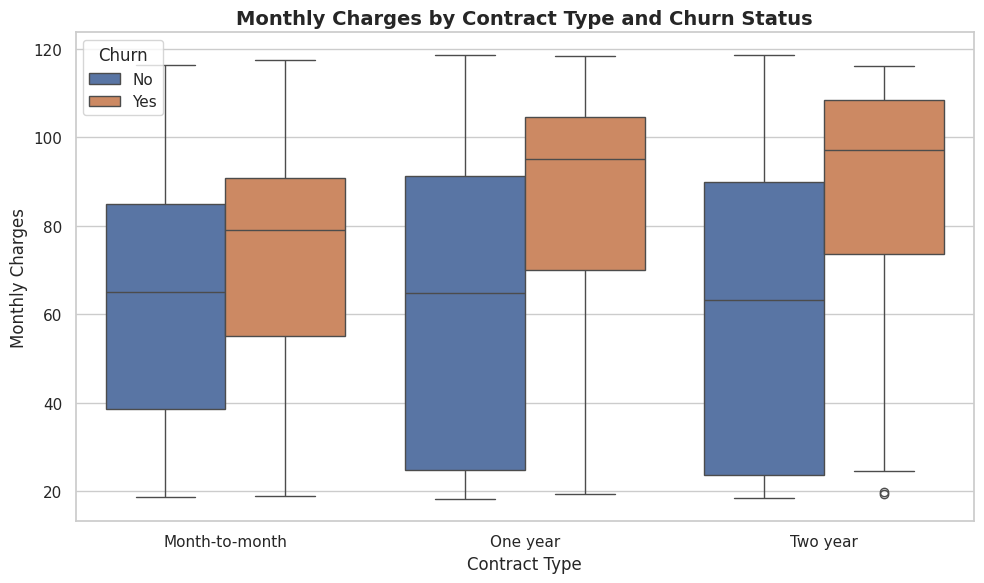

In [52]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="Contract",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title(
    "Monthly Charges by Contract Type and Churn Status",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Contract Type")
plt.ylabel("Monthly Charges")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

In [53]:
# Tenure by contract type and churn

contract_tenure_summary = (
    df_clean
    .groupby(["Contract", "Churn"])["tenure"]
    .agg(["count", "mean", "median"])
    .round(2)
)

contract_tenure_summary

count   mean  median
Contract       Churn                      
Month-to-month No      2220  21.03    16.0
               Yes     1655  14.02     7.0
One year       No      1307  41.67    43.0
               Yes      166  44.96    48.0
Two year       No      1647  56.60    64.0
               Yes       48  61.27    65.5

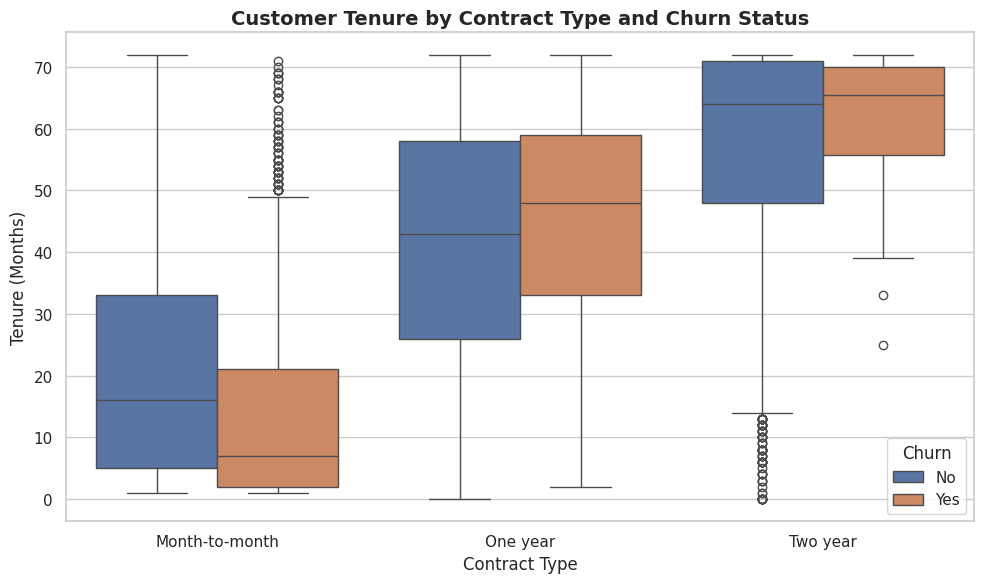

In [54]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="Contract",
    y="tenure",
    hue="Churn"
)

plt.title(
    "Customer Tenure by Contract Type and Churn Status",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Contract Type")
plt.ylabel("Tenure (Months)")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

In [55]:
internet_churn = pd.crosstab(
    df_clean["InternetService"],
    df_clean["Churn"],
    normalize="index"
).mul(100).round(2)

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


## 10. Predictive Modeling

The objective of the modeling stage is to predict whether a customer will
churn based on demographic, account, service, and billing characteristics.

A leakage-safe modeling workflow is used. The dataset is first divided
into training and untouched test sets before any data-dependent
preprocessing is learned.

Preprocessing is incorporated into modeling pipelines so that transformations
are fitted using only the training data.

Because the target classes are imbalanced, model performance will not be
evaluated using accuracy alone. Precision, recall, F1-score, ROC-AUC, and
PR-AUC are also considered.

In [56]:
# Prepare modeling dataset

model_df = df_clean.copy()

# Remove identifier and EDA-only variable
model_df = model_df.drop(
    columns=["customerID", "SeniorCitizenLabel"],
    errors="ignore"
)

# Separate predictors and target
X = model_df.drop(columns="Churn")
y = model_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget encoding:")
print("No  -> 0")
print("Yes -> 1")

print("\nTarget distribution:")
print(y.value_counts())

Predictor shape: (7043, 19)
Target shape: (7043,)

Target encoding:
No  -> 0
Yes -> 1

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training observations:", X_train.shape[0])
print("Test observations:", X_test.shape[0])

print("\nTraining target distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest target distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training observations: 5634
Test observations: 1409

Training target distribution (%):
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

Test target distribution (%):
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [58]:
# Identify feature types using training data

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:",
      len(numerical_features))

print("Number of categorical features:",
      len(categorical_features))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of numerical features: 4
Number of categorical features: 15


### 10.1 Preprocessing Strategy

Numerical and categorical variables require different preprocessing.

- Numerical variables are standardized for models that are sensitive to
  feature scale.
- Categorical variables are transformed using one-hot encoding.
- Unknown categories are ignored to ensure that previously unseen
  categories in validation or test data can be handled safely.
- Preprocessing is incorporated into a pipeline and fitted only on the
  training data, reducing the risk of information leakage from the test set.

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical preprocessing
numeric_transformer = StandardScaler()

# Categorical preprocessing
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### 10.2 Baseline Model — Logistic Regression

Logistic Regression is used as the initial baseline classifier because it
provides a relatively simple and interpretable benchmark against which
more complex models can subsequently be compared.

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred_lr = logistic_pipeline.predict(X_test)
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

# Metrics
print("LOGISTIC REGRESSION — TEST PERFORMANCE")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_prob_lr):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["No Churn", "Churn"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

LOGISTIC REGRESSION — TEST PERFORMANCE
Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1-score : 0.6040
ROC-AUC  : 0.8421
PR-AUC   : 0.6343

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix:
[[926 109]
 [165 209]]


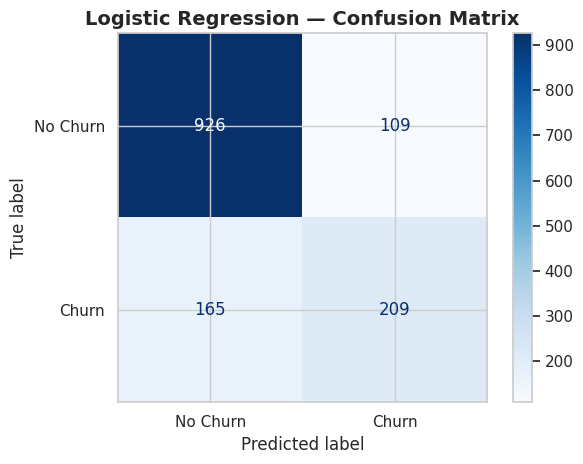

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["No Churn", "Churn"],
    cmap="Blues"
)

plt.title(
    "Logistic Regression — Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

### 10.2 Random Forest

Random Forest is evaluated as a nonlinear ensemble model. Unlike Logistic
Regression, it can capture more complex relationships and interactions
between customer characteristics without assuming a linear decision
boundary.

The same training and untouched test sets are retained to ensure a fair
comparison with the baseline model.

In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [64]:
# Random Forest predictions

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("RANDOM FOREST — TEST PERFORMANCE")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_prob_rf):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No Churn", "Churn"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

RANDOM FOREST — TEST PERFORMANCE
Accuracy : 0.7821
Precision: 0.6143
Recall   : 0.4813
F1-score : 0.5397
ROC-AUC  : 0.8195
PR-AUC   : 0.6099

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.61      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409


Confusion Matrix:
[[922 113]
 [194 180]]


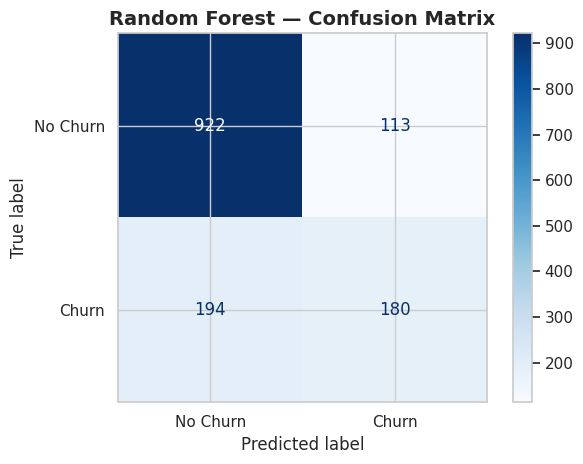

In [65]:
# Random Forest — Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["No Churn", "Churn"],
    cmap="Blues"
)

plt.title(
    "Random Forest — Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [66]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_rf)
    ]
}).round(4)

model_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421,0.6343
1,Random Forest,0.7821,0.6143,0.4813,0.5397,0.8195,0.6099


### 10.3 XGBoost Classifier

XGBoost is evaluated as a gradient-boosting model capable of capturing
nonlinear relationships and interactions between customer characteristics.

The same training and untouched test sets are retained to ensure a fair
comparison with the previous models.

In [67]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgb_pipeline.fit(X_train, y_train)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [68]:
# XGBoost predictions

y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("XGBOOST — TEST PERFORMANCE")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_prob_xgb):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=["No Churn", "Churn"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBOOST — TEST PERFORMANCE
Accuracy : 0.8013
Precision: 0.6567
Recall   : 0.5267
F1-score : 0.5846
ROC-AUC  : 0.8421
PR-AUC   : 0.6541

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:
[[932 103]
 [177 197]]


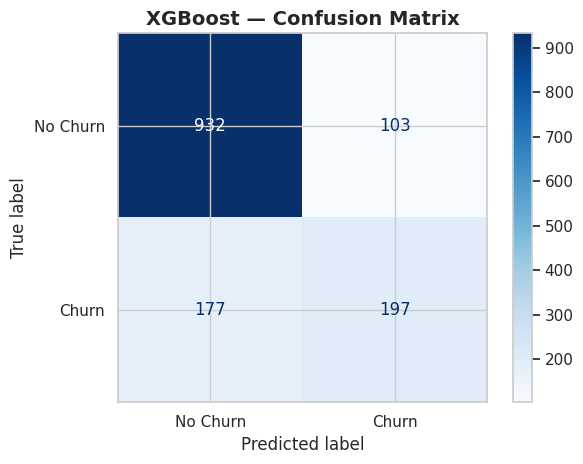

In [69]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=["No Churn", "Churn"],
    cmap="Blues"
)

plt.title(
    "XGBoost — Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [70]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb)
    ]
}).round(4)

model_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421,0.6343
1,Random Forest,0.7821,0.6143,0.4813,0.5397,0.8195,0.6099
2,XGBoost,0.8013,0.6567,0.5267,0.5846,0.8421,0.6541


### 10.4 Stacking Ensemble

A stacking ensemble is evaluated to determine whether a learned combination
of the individual classifiers can improve churn prediction.

The base learners consist of Logistic Regression, Random Forest, and XGBoost.
Their predictions are combined by a Logistic Regression meta-classifier.

Unlike soft voting, which directly averages predicted probabilities, stacking
uses cross-validated predictions from the base models to train a second-level
meta-model. This allows the ensemble to learn how the predictions of the
individual classifiers should be combined.

The stacking model is evaluated using the same data split and performance
metrics as the previous classifiers.

In [71]:
from sklearn.ensemble import StackingClassifier

# Base models
stacking_estimators = [
    (
        "lr",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    ),
    (
        "rf",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    ),
    (
        "xgb",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
    )
]

# Stacking classifier
stacking_classifier = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)

# Complete leakage-safe pipeline
stacking_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", stacking_classifier)
    ]
)

stacking_pipeline.fit(X_train, y_train)

print("Stacking Ensemble trained successfully.")

Stacking Ensemble trained successfully.


In [72]:
# Stacking predictions

y_pred_stack = stacking_pipeline.predict(X_test)
y_prob_stack = stacking_pipeline.predict_proba(X_test)[:, 1]

print("STACKING ENSEMBLE — TEST PERFORMANCE")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test, y_pred_stack):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_stack):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_stack):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_stack):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_stack):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_prob_stack):.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_stack,
        target_names=["No Churn", "Churn"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_stack))

STACKING ENSEMBLE — TEST PERFORMANCE
Accuracy : 0.7977
Precision: 0.6459
Recall   : 0.5267
F1-score : 0.5803
ROC-AUC  : 0.8463
PR-AUC   : 0.6504

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:
[[927 108]
 [177 197]]


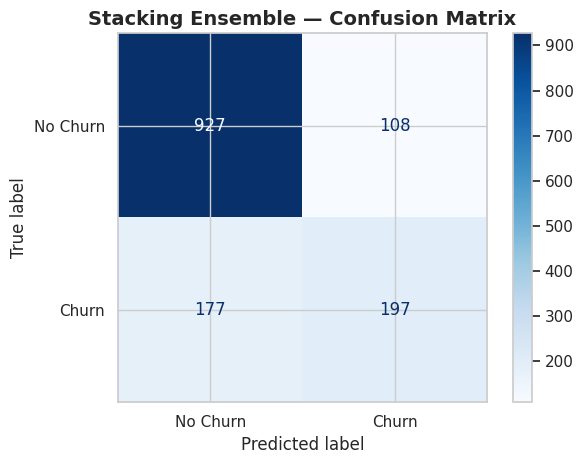

In [73]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_stack,
    display_labels=["No Churn", "Churn"],
    cmap="Blues"
)

plt.title(
    "Stacking Ensemble — Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [74]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Stacking Ensemble"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_stack)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_stack)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_stack)
    ],

    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_stack)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_stack)
    ],

    "PR-AUC": [
        average_precision_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb),
        average_precision_score(y_test, y_prob_stack)
    ]
}).round(4)

model_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421,0.6343
1,Random Forest,0.7821,0.6143,0.4813,0.5397,0.8195,0.6099
2,XGBoost,0.8013,0.6567,0.5267,0.5846,0.8421,0.6541
3,Stacking Ensemble,0.7977,0.6459,0.5267,0.5803,0.8463,0.6504


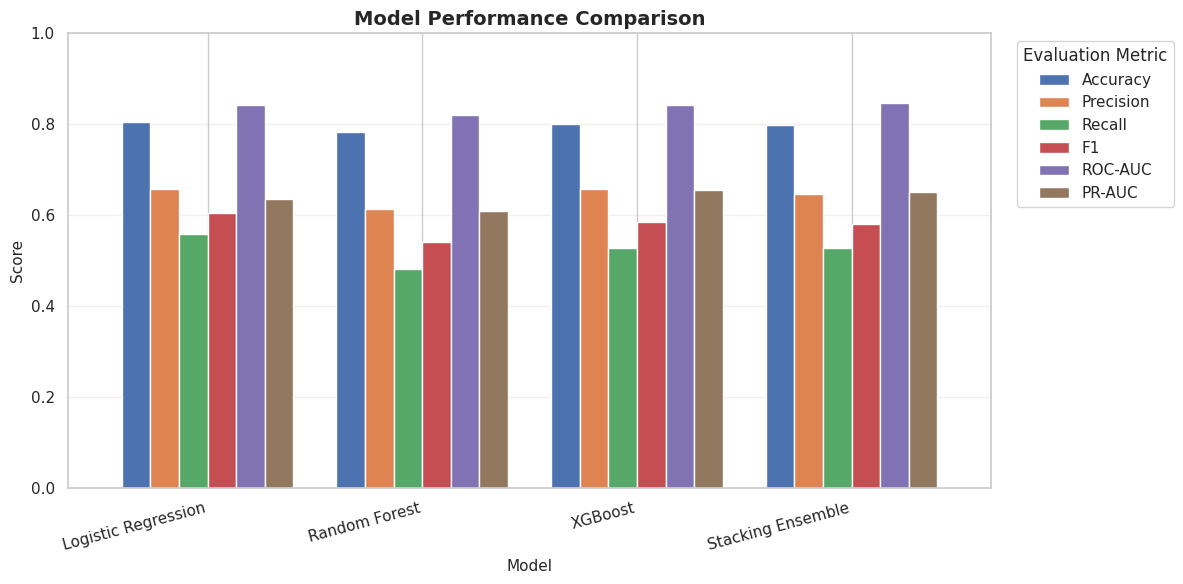

In [75]:
comparison_plot = model_results.set_index("Model")

ax = comparison_plot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.title(
    "Model Performance Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Model", fontsize=11)
plt.ylabel("Score", fontsize=11)

plt.ylim(0, 1)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.legend(
    title="Evaluation Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 11. Cross-Validation and Robust Model Comparison

The initial model comparison was based on a single train-test split.
To obtain a more reliable estimate of model performance, the candidate
models are further evaluated using 5-fold stratified cross-validation
on the training data.

Stratification preserves the proportion of churn and non-churn customers
within each fold.

The models are compared using:

- Recall
- F1-score
- ROC-AUC
- PR-AUC

These metrics are emphasized because the churn class is the minority class
and identifying customers at risk of leaving is an important business
objective.

The held-out test set is not used during this cross-validation stage.

In [76]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "Recall": "recall",
    "F1": "f1",
    "ROC_AUC": "roc_auc",
    "PR_AUC": "average_precision"
}

print("5-fold stratified cross-validation configured.")

5-fold stratified cross-validation configured.


In [77]:
cv_models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "Stacking Ensemble": stacking_pipeline
}

print("Models included in cross-validation:")

for model_name in cv_models:
    print("-", model_name)

Models included in cross-validation:
- Logistic Regression
- Random Forest
- XGBoost
- Stacking Ensemble


In [78]:
cv_results = []

for model_name, model in cv_models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,

        "Recall Mean": scores["test_Recall"].mean(),
        "Recall Std": scores["test_Recall"].std(),

        "F1 Mean": scores["test_F1"].mean(),
        "F1 Std": scores["test_F1"].std(),

        "ROC-AUC Mean": scores["test_ROC_AUC"].mean(),
        "ROC-AUC Std": scores["test_ROC_AUC"].std(),

        "PR-AUC Mean": scores["test_PR_AUC"].mean(),
        "PR-AUC Std": scores["test_PR_AUC"].std()
    })

cv_results_df = pd.DataFrame(cv_results).round(4)

cv_results_df

,Model,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,PR-AUC Std
0,Logistic Regression,0.5431,0.0411,0.5923,0.0299,0.8462,0.0126,0.6617,0.0194
1,Random Forest,0.4796,0.0249,0.5429,0.0249,0.8204,0.0123,0.6134,0.0307
2,XGBoost,0.5197,0.0351,0.5796,0.0309,0.8438,0.0102,0.6618,0.0161
3,Stacking Ensemble,0.5231,0.0300,0.5877,0.0249,0.8478,0.0103,0.6672,0.0175


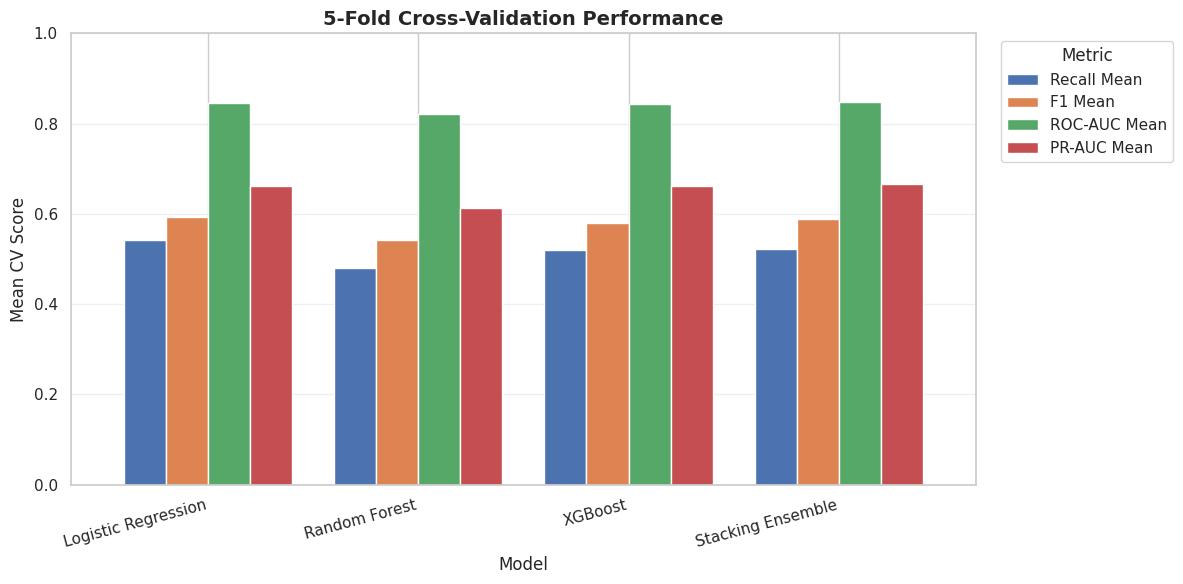

In [79]:
cv_plot = cv_results_df[
    [
        "Model",
        "Recall Mean",
        "F1 Mean",
        "ROC-AUC Mean",
        "PR-AUC Mean"
    ]
].set_index("Model")

ax = cv_plot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.title(
    "5-Fold Cross-Validation Performance",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Mean CV Score")

plt.ylim(0, 1)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 12. Classification Threshold Optimization

The default classification threshold of 0.50 may not be optimal for a
customer churn problem.

In churn prediction, failing to identify a customer who is likely to leave
can represent a missed retention opportunity. Therefore, increasing recall
may be valuable even if it results in some reduction in precision.

To avoid using the holdout test set for model optimization, threshold
selection is performed using out-of-fold predictions generated exclusively
from the training data.

Logistic Regression is investigated first because it achieved the highest
mean recall and F1-score during cross-validation.

In [80]:
from sklearn.model_selection import cross_val_predict

lr_oof_prob = cross_val_predict(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("Out-of-fold probabilities generated.")
print("Number of predictions:", len(lr_oof_prob))

Out-of-fold probabilities generated.
Number of predictions: 5634


In [81]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

thresholds = np.arange(0.20, 0.61, 0.05)

for threshold in thresholds:

    y_pred_threshold = (lr_oof_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_train, y_pred_threshold),
        "Recall": recall_score(y_train, y_pred_threshold),
        "F1": f1_score(y_train, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results).round(4)

threshold_df

,Threshold,Precision,Recall,F1
0,0.20,0.4751,0.8542,0.6106
1,0.25,0.5100,0.8174,0.6281
2,0.30,0.5406,0.7666,0.6340
3,0.35,0.5702,0.7171,0.6353
4,0.40,0.5939,0.6642,0.6271
5,0.45,0.6232,0.6007,0.6117
6,0.50,0.6527,0.5431,0.5929
7,0.55,0.6858,0.4863,0.5691
8,0.60,0.7110,0.3967,0.5092


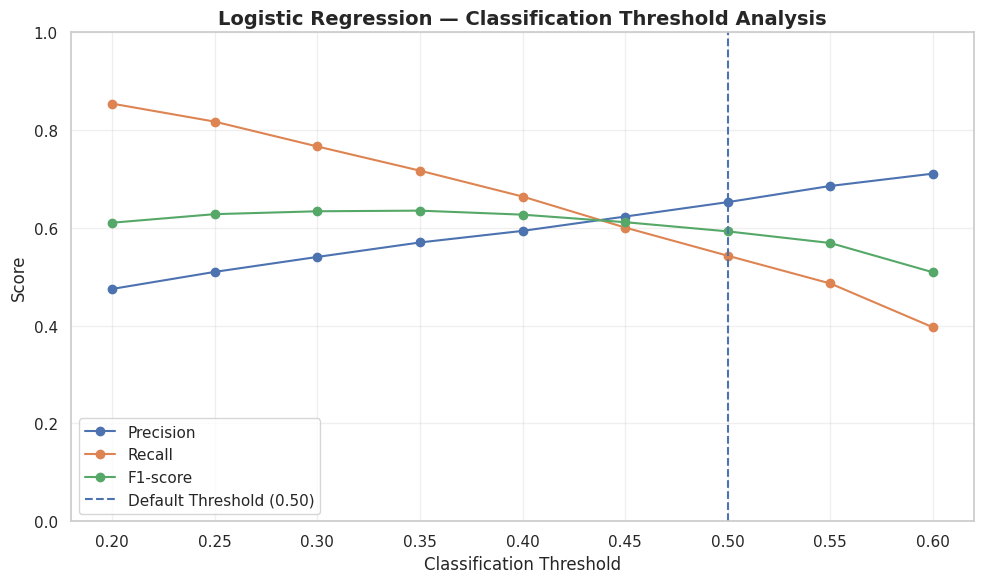

In [82]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1-score"
)

plt.axvline(
    x=0.50,
    linestyle="--",
    label="Default Threshold (0.50)"
)

plt.title(
    "Logistic Regression — Classification Threshold Analysis",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [83]:
# Fit Logistic Regression on the complete training set
logistic_pipeline.fit(X_train, y_train)

# Obtain churn probabilities on the holdout set
y_prob_lr_final = logistic_pipeline.predict_proba(X_test)[:, 1]

# Apply the selected threshold
selected_threshold = 0.35

y_pred_lr_035 = (
    y_prob_lr_final >= selected_threshold
).astype(int)

In [84]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

print("Logistic Regression — Threshold = 0.35")
print("=" * 50)

print(
    "Accuracy:",
    round(accuracy_score(y_test, y_pred_lr_035), 4)
)

print(
    "Precision:",
    round(precision_score(y_test, y_pred_lr_035), 4)
)

print(
    "Recall:",
    round(recall_score(y_test, y_pred_lr_035), 4)
)

print(
    "F1-score:",
    round(f1_score(y_test, y_pred_lr_035), 4)
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, y_prob_lr_final), 4)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_test, y_prob_lr_final), 4)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr_035,
        target_names=["No Churn", "Churn"]
    )
)

Logistic Regression — Threshold = 0.35
Accuracy: 0.7644
Precision: 0.5432
Recall: 0.7059
F1-score: 0.614
ROC-AUC: 0.8421
PR-AUC: 0.6343

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.54      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



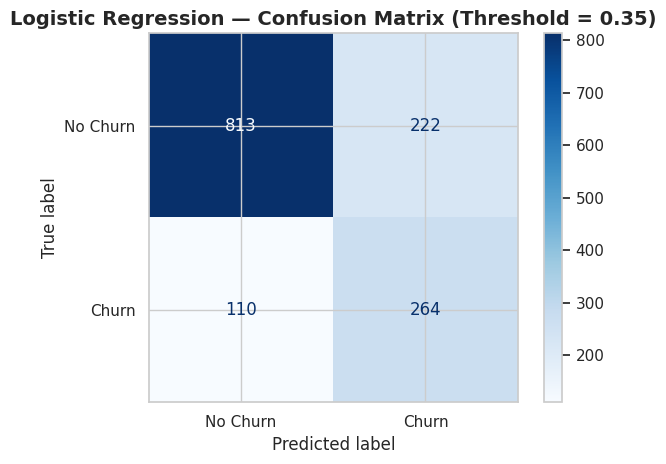

In [85]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr_035,
    display_labels=["No Churn", "Churn"],
    cmap="Blues"
)

plt.title(
    "Logistic Regression — Confusion Matrix (Threshold = 0.35)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 13. Model Explainability

Predictive performance alone is not sufficient for a customer churn
application. Understanding the factors associated with model predictions
is also important for translating analytical results into actionable
business insights.

Logistic Regression was selected as the operational model because it
provided the strongest churn recall and F1-score at the selected threshold
while remaining highly interpretable.

The model coefficients are therefore examined to identify features
associated with higher and lower predicted churn risk.

Positive coefficients indicate an association with higher predicted churn
risk, while negative coefficients indicate an association with lower
predicted churn risk. These relationships should be interpreted as model
associations rather than causal effects.

In [86]:
# Extract the fitted preprocessing and Logistic Regression components

fitted_preprocessor = logistic_pipeline.named_steps["preprocessor"]
fitted_logistic_model = logistic_pipeline.named_steps["classifier"]

# Obtain transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Obtain Logistic Regression coefficients
coefficients = fitted_logistic_model.coef_[0]

# Create coefficient table
coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Remove preprocessing prefixes for cleaner presentation
coefficient_df["Feature"] = (
    coefficient_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# Sort from highest positive to strongest negative coefficient
coefficient_df = coefficient_df.sort_values(
    "Coefficient",
    ascending=False
).reset_index(drop=True)

display(coefficient_df.head(10))
display(coefficient_df.tail(10))

,Feature,Coefficient
0,InternetService_Fiber optic,0.634195
1,Contract_Month-to-month,0.582883
2,TotalCharges,0.536253
3,StreamingMovies_Yes,0.200938
4,StreamingTV_Yes,0.200481
5,PaymentMethod_Electronic check,0.197867
6,OnlineSecurity_No,0.156279
7,TechSupport_No,0.131503
8,MultipleLines_Yes,0.104649
9,SeniorCitizen,0.053449


,Feature,Coefficient
35,OnlineSecurity_No internet service,-0.300104
36,InternetService_No,-0.300104
37,StreamingTV_No internet service,-0.300104
38,DeviceProtection_No internet service,-0.300104
39,OnlineBackup_No internet service,-0.300104
40,PaperlessBilling_No,-0.343227
41,MonthlyCharges,-0.591863
42,InternetService_DSL,-0.648646
43,Contract_Two year,-0.776594
44,tenure,-1.257539


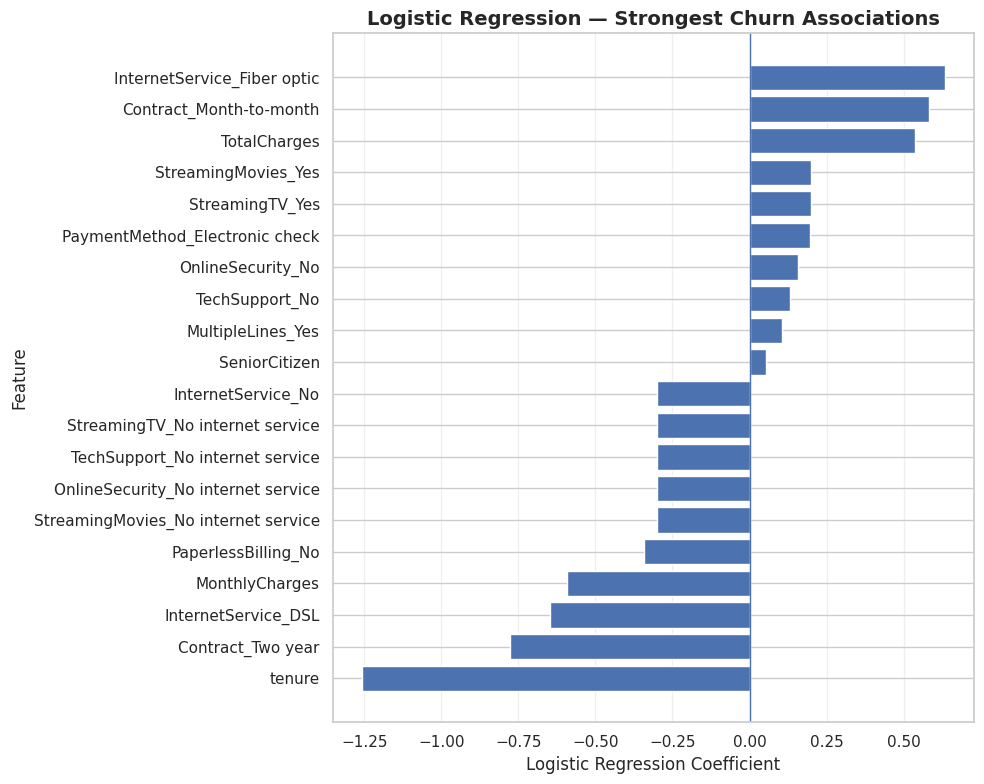

In [87]:
# Select strongest positive and negative coefficients

top_positive = coefficient_df.nlargest(
    10,
    "Coefficient"
)

top_negative = coefficient_df.nsmallest(
    10,
    "Coefficient"
)

important_coefficients = pd.concat([
    top_positive,
    top_negative
]).sort_values("Coefficient")

plt.figure(figsize=(10, 8))

plt.barh(
    important_coefficients["Feature"],
    important_coefficients["Coefficient"]
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.title(
    "Logistic Regression — Strongest Churn Associations",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 14. Final Operating Model

Although several models demonstrated competitive predictive performance,
Logistic Regression was selected as the operational model for the
retention-oriented use case.

During 5-fold cross-validation, Logistic Regression achieved the highest
mean recall (0.5431) and F1-score (0.5923) at the default threshold among
the evaluated models. The Stacking Ensemble achieved the highest mean
ROC-AUC (0.8478) and PR-AUC (0.6672), demonstrating that no single model
dominated every evaluation metric.

Because identifying customers at risk of leaving is particularly important
for retention interventions, the Logistic Regression classification
threshold was optimized using out-of-fold training predictions.

A threshold of **0.35** was selected because it produced the highest
observed training out-of-fold F1-score while substantially improving churn
recall.

On the holdout data, the threshold-adjusted Logistic Regression achieved:

- Accuracy: **0.7644**
- Precision: **0.5432**
- Recall: **0.7059**
- F1-score: **0.6140**
- ROC-AUC: **0.8421**
- PR-AUC: **0.6343**

The lower threshold allows the model to identify a larger proportion of
customers who actually churn, at the cost of generating more false-positive
retention alerts.

In [88]:
threshold_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Threshold 0.50": [
        0.8055,
        0.6572,
        0.5588,
        0.6040
    ],

    "Threshold 0.35": [
        0.7644,
        0.5432,
        0.7059,
        0.6140
    ]
})

threshold_comparison

,Metric,Threshold 0.50,Threshold 0.35
0,Accuracy,0.8055,0.7644
1,Precision,0.6572,0.5432
2,Recall,0.5588,0.7059
3,F1-score,0.6040,0.6140


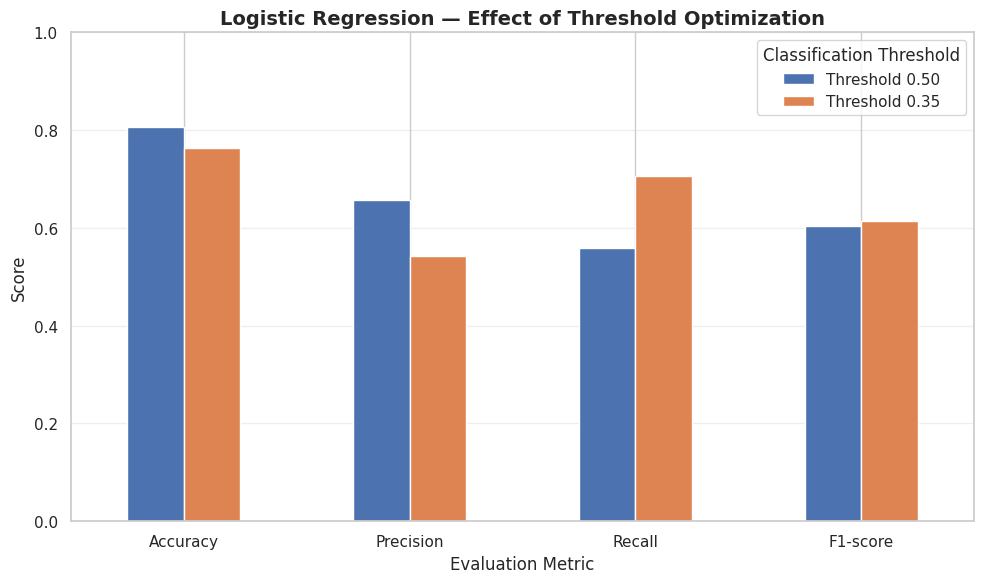

In [89]:
threshold_comparison_plot = (
    threshold_comparison
    .set_index("Metric")
)

threshold_comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Logistic Regression — Effect of Threshold Optimization",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Classification Threshold"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 15. High-Risk Customer Profile

The exploratory analysis indicates that churn is concentrated among several
customer segments.

Customers with **month-to-month contracts** showed a churn rate of 42.71%,
compared with 11.27% for one-year contracts and only 2.83% for two-year
contracts.

Customers using **electronic check** had a churn rate of 45.29%, while
customers with **fiber-optic internet** had a churn rate of 41.89%.

The absence of support-related services was also associated with higher
churn. Customers without Online Security had a churn rate of 41.77%, and
customers without Tech Support had a churn rate of 41.64%.

Tenure showed another strong pattern. Customers who churned had a median
tenure of only 10 months, compared with 38 months among customers who
remained.

Churned customers also had higher average monthly charges (74.44) than
non-churn customers (61.27).

Taken together, the results suggest that customers with shorter tenure,
flexible contracts, relatively high monthly charges, and limited support
services represent particularly important segments for retention analysis.

These patterns describe associations in the available dataset and should
not be interpreted as causal relationships.

## 16. Business Insights and Retention Recommendations

The analytical results can be translated into several potential retention
strategies.

### 1. Prioritize High-Risk Customers

The churn model can be used to assign customers a probability of churn.
Customers exceeding the selected operating threshold can be prioritized
for retention campaigns.

Rather than contacting every customer, retention resources can therefore
be concentrated on customers showing stronger predicted churn risk.

### 2. Focus on Early Customer Retention

Churned customers showed substantially shorter tenure than customers who
remained. This suggests that the early stages of the customer relationship
are particularly important for retention monitoring.

Companies could consider stronger onboarding, service check-ins, and
targeted support during the first months of the customer lifecycle.

### 3. Encourage Longer-Term Contracts

Month-to-month customers showed substantially higher churn than customers
with one-year or two-year contracts.

The company could test incentives for longer-term commitments, such as
discounts, loyalty benefits, or bundled service packages.

### 4. Review High-Churn Service Segments

Fiber-optic customers displayed considerably higher churn than DSL and
customers without internet service.

This pattern should trigger further investigation into customer experience,
pricing, service reliability, and expectations within the fiber-optic
segment rather than assuming that the service itself causes churn.

### 5. Strengthen Support-Service Adoption

Customers without Online Security or Tech Support showed higher churn
rates.

The company could investigate whether targeted trials, bundled support
services, or better communication of these services improves customer
retention.

### 6. Review Pricing and Payment Experience

Churn customers had higher average monthly charges, while electronic-check
customers showed particularly high churn.

These patterns justify further investigation into pricing sensitivity,
billing experience, payment convenience, and the potential effectiveness
of targeted offers or alternative payment options.

### 7. Use Risk Scores Rather Than Only Binary Predictions

Predicted probabilities can be more useful operationally than a simple
churn/no-churn label.

Customers can be ranked according to predicted churn probability, allowing
retention teams to prioritize interventions according to available budget,
customer value, and campaign capacity.

## 17. Conclusion

Logistic Regression achieved 80.55% accuracy at the default threshold, while threshold optimization increased churn recall from 55.88% to 70.59%, making the model more effective for identifying at-risk customers and supporting targeted retention strategies.